In [1]:
import os
os.chdir('..')
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

from src.data.preprocessing import build_main_df
from src.models.random_forest.random_forest_system import uruchom_system

final = build_main_df()
diagnozy_rf = uruchom_system(final)

Epizody wysokiej wody (p90, >= 2 stacji)
  Strzyza             : próg=0.410, epizodów=194 (10.6%)
  Martwa_Wisla        : próg=0.230, epizodów=184 (10.1%)
  Port_Polnocny       : próg=5.520, epizodów=184 (10.1%)
  Łącznie (>= 2 stacji): epizodów=180 (9.9%)
Walidacja czasowa (walk-forward, rolling threshold)
  2022: pominięto (tylko 1 lat treningowych < MIN_TRAIN_YEARS=2)
2023: RF recall=0.630 prec=0.377 F1=0.472 | benchmark recall=0.261 prec=0.231 | epizody(>=2 stacje)=46 (Strzyza=49, Martwa_Wisla=47, Port_Polnocny=33)
2024: RF recall=0.658 prec=0.391 F1=0.490 | benchmark recall=0.316 prec=0.207 | epizody(>=2 stacje)=38 (Strzyza=43, Martwa_Wisla=26, Port_Polnocny=43)
2025: RF recall=0.474 prec=0.545 F1=0.507 | benchmark recall=0.211 prec=0.167 | epizody(>=2 stacje)=38 (Strzyza=33, Martwa_Wisla=76, Port_Polnocny=47)

Podsumowanie walidacji:
 Rok  Recall_RF  Precision_RF  F1_RF  Recall_bench  Prec_bench  n_epizodow
2023      0.630         0.377  0.472         0.261       0.231          4

In [2]:
from src.models.lstm.lstm_system import uruchom_system_lstm
diagnozy_lstm = uruchom_system_lstm(final)


LSTM – system wykrywania epizodów wysokiej wody
seq_len=7, threshold=0.5
target: ≥2 stacje p90

Walidacja czasowa LSTM (walk-forward)
  2022: pominięto (1 lat treningowych)
2023: LSTM recall=0.804 prec=0.243 F1=0.374 | benchmark recall=0.150 prec=0.118 | epizody(>=2 stacje)=46
2024: LSTM recall=0.658 prec=0.305 F1=0.417 | benchmark recall=0.189 prec=0.125 | epizody(>=2 stacje)=38
2025: LSTM recall=0.579 prec=0.449 F1=0.506 | benchmark recall=0.333 prec=0.229 | epizody(>=2 stacje)=38

Podsumowanie walidacji LSTM:
 Rok  Recall_LSTM  Precision_LSTM  F1_LSTM  Recall_bench  Prec_bench  n_epizodow
2023        0.804           0.243    0.374         0.150       0.118          46
2024        0.658           0.305    0.417         0.189       0.125          38
2025        0.579           0.449    0.506         0.333       0.229          38
  Średnie: recall=0.680, prec=0.332, F1=0.432
Wykres walidacji → reports/ml/lstm/walidacja_czasowa_lstm_vs_benchmark.png
Trening finalnego modelu LSTM (cały 

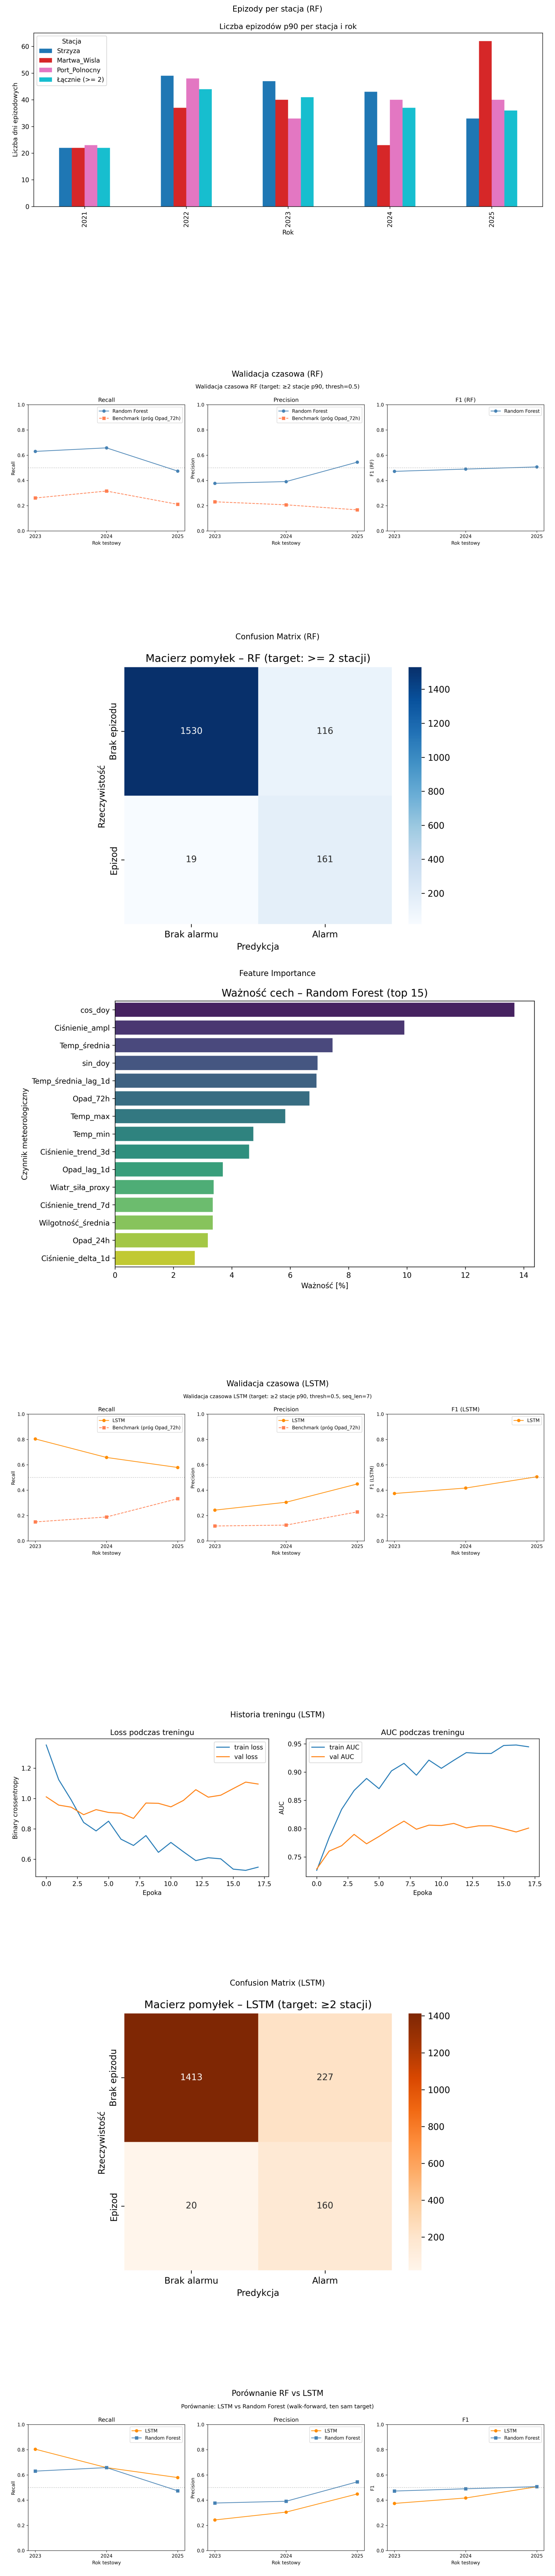

In [5]:
from IPython.display import Image, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(8, 1, figsize=(10, 48))

images = [
    'reports/ml/rf/epizody_per_stacja_rf.png',
    'reports/ml/rf/walidacja_czasowa_rf_vs_benchmark.png',
    'reports/ml/rf/confusion_matrix_rf.png',
    'reports/ml/rf/feature_importance.png',
    'reports/ml/lstm/walidacja_czasowa_lstm_vs_benchmark.png',
    'reports/ml/lstm/historia_treningu.png',
    'reports/ml/lstm/confusion_matrix_lstm.png',
    'reports/ml/porownanie_lstm_vs_rf.png',
]

titles = [
    'Epizody per stacja (RF)',
    'Walidacja czasowa (RF)',
    'Confusion Matrix (RF)',
    'Feature Importance',
    'Walidacja czasowa (LSTM)',
    'Historia treningu (LSTM)',    
    'Confusion Matrix (LSTM)',
    'Porównanie RF vs LSTM',
]

for ax, img_path, title in zip(axes.flat, images, titles):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('temp_grid.png', dpi=150, bbox_inches='tight')
plt.close()

display(Image('temp_grid.png'))

## Wyniki i analiza modeli

### Random Forest

**Feature Importance** — najważniejsze czynniki to:
- `cos_doy` (13.68%) — sezonowość jest dominującym predyktorem,
  co potwierdza że wezbrania mają silny wzorzec sezonowy (zima)
- `Ciśnienie_ampl` (9.91%) — amplituda ciśnienia jako proxy 
  warunków sztormowych
- `Temp_średnia` i `sin_doy` — temperatura i sezonowość
- `Opad_72h` (6.66%) — opad skumulowany jako 6. najważniejszy czynnik

**Confusion Matrix (RF)**
- 1530 poprawnych "brak epizodu" 
- 161 poprawnie wykrytych epizodów 
- 116 fałszywych alarmów 
- 19 przeoczonych epizodów 

**Walidacja czasowa (RF)**
- RF konsekwentnie przewyższa benchmark (próg Opad_72h)
- Recall spada w 2025 (0.474) — model gorzej radzi sobie 
  z nowymi wzorcami
- Precision rośnie w 2025 — mniej fałszywych alarmów

**Epizody per stacja**
- Martwa Wisła w 2025 miała anomalnie dużo epizodów (76!) 
  — może wpływać na wyniki modelu

---

### LSTM

**Confusion Matrix (LSTM)**
- 341 fałszywych alarmów — znacznie więcej niż RF (116)
- Ten sam recall (0.894) ale precision tylko 0.321

**Walidacja czasowa (LSTM)**
- Wysoki recall w 2023 (0.848) ale spada w kolejnych latach
- Mniej stabilny niż RF

**Historia treningu**
- Early stopping po 17 epokach — model nie przetrenowany
- val_AUC stabilizuje się ~0.80

---

### Porównanie RF vs LSTM

| Model | Recall | Precision | F1    | Accuracy |
|-------|--------|-----------|-------|----------|
| RF    | 0.894  | 0.581     | 0.700 | 0.93     |
| LSTM  | 0.894  | 0.321     | 0.470 | 0.80     |

**RF wygrywa** — przy identycznym recall ma znacznie wyższą 
precision i accuracy. LSTM generuje 3x więcej fałszywych alarmów.